In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

## Roadmap

1. Load an edm4hep file
2. Load the particles and tracker hits
3. Inspect **Hidden Valley** truth particles (focus on `4900*` PDGs and semi-visible jet structure)
4. Sanity-check that only the intended dark hadrons are stable (e.g. stable neutral `4900111`, prompt decays for others)


## Loading

In [2]:
# Load the edm4hep file with uproot
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/zprime/v1/runs/0/edm4hep.root"
# Z′ run currently produces 8 events in run 0
event = EDM4hepEventBatch(edm_input_file, events=(0, 8), condense_calo=False, full_load=True)


In [3]:
tracker_hits = event.get_tracker_hits_df()
calo_hits = event.get_calo_hits_df()
particles = event.get_particles_df()
daughters = event.get_daughters_df()
parents = event.get_parents_df()

In [4]:
particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,-0.213826,0.938270,-0.005583,0.020839,97.337314,...,0,3,0.021574,0.021574,7000.000000,6999.061730,0,False,0,0
1,0,1,21,0,0.000000,-0.213826,0.000000,-0.005583,0.020839,97.337314,...,3,4,0.021574,0.021574,3026.726559,3026.726559,1,False,0,0
2,0,2,2,0,0.666667,-0.213826,0.330000,-0.005583,0.020839,97.337314,...,4,5,0.021574,0.021574,361.156860,360.826860,2,False,0,0
3,0,3,2101,0,0.333333,-0.213826,0.579330,-0.005583,0.020839,97.337314,...,5,6,0.021574,0.021574,3612.116428,3611.537098,3,False,0,0
4,0,4,2212,0,1.000000,-0.213826,0.938270,-0.005583,0.020839,97.337314,...,6,8,0.021574,0.021574,7000.000000,6999.061730,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84306,7,21649,11,1426063360,-1.000000,5.363904,0.000511,1255.996503,394.459701,893.061970,...,24339,24339,1316.482309,1337.880446,0.414484,0.413973,21649,True,0,0
84307,7,21650,11,1426063360,-1.000000,5.465016,0.000511,1279.690352,402.051273,910.377573,...,24339,24339,1341.362227,1364.366017,0.200306,0.199795,21650,True,0,0
84308,7,21651,-11,1426063360,1.000000,5.261290,0.000511,1232.203826,386.649610,875.167487,...,24339,24339,1291.442678,1307.790817,0.126262,0.125751,21651,True,0,0
84309,7,21652,11,1426063360,-1.000000,5.137022,0.000511,1202.493910,377.508592,854.641104,...,24339,24339,1260.358815,1281.890119,0.382015,0.381504,21652,True,0,0


In [5]:
particles.PDG.unique()

array([      2212,         21,          2,       2101,          5,
               -5,         -2,        221,       2224,      -2224,
              321,       -323,        223,        211,        111,
             -211,       -213,        311,       -313,        213,
              113,       2214,      -2214,       -321,        513,
             -523,      -2212,       2112,         32,       -311,
               22,        310,        511,       -521,         11,
              -11,        441,        -12,      10421,        411,
               13,        -13,       3222, 1000140280,        -14,
       1000010030,        331, 1000010020, 1000130280, 1000140270,
       1000020030,         14,         -1,          1,       2203,
             3112,      -3312,        323,       3212,      -3214,
              313,       3122,      -2112,         -3,          3,
              333,      -3122,        130, 1000140290,          4,
              413,       3214,       3312,      -3212,        

In [6]:
particles.columns

Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'generatorStatus', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'daughters_begin', 'daughters_end', 'vr', 'endpoint_r',
       'energy', 'kinetic_energy', 'particle_id', 'created_in_simulation',
       'num_tracker_hits', 'num_calo_hits'],
      dtype='object')

In [7]:
particles[particles.PDG == 32]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
226,0,226,32,0,0.0,-0.213826,2929.745362,-0.005583,0.020839,97.337314,...,1369,1370,0.021574,0.021574,2987.502148,57.756786,226,False,0,0
295,0,295,32,0,0.0,-0.213826,2929.745362,-0.005583,0.020839,97.337314,...,1584,1585,0.021574,0.021574,2984.909510,55.164148,295,False,0,0
344,0,344,32,0,0.0,-0.213826,2929.745362,-0.005583,0.020839,97.337314,...,1669,1670,0.021574,0.021574,2985.953900,56.208538,344,False,0,0
366,0,366,32,0,0.0,-0.213826,2929.745362,-0.005583,0.020839,97.337314,...,1774,1775,0.021574,0.021574,2986.151889,56.406527,366,False,0,0
374,0,374,32,0,0.0,-0.213826,2929.745362,-0.005583,0.020839,97.337314,...,1797,1798,0.021574,0.021574,2986.180072,56.434710,374,False,0,0
375,0,375,32,0,0.0,-0.213826,2929.745362,-0.005583,0.020839,97.337314,...,1798,1799,0.021574,0.021574,2986.164405,56.419043,375,False,0,0
376,0,376,32,0,0.0,-0.213826,2929.745362,-0.005583,0.020839,97.337314,...,1799,1801,0.021574,0.021574,2986.190435,56.445073,376,False,0,0
2791,1,710,32,0,0.0,0.126100,2693.818940,-0.017127,0.007813,-42.943874,...,2701,2702,0.018825,0.018825,2756.974424,63.155484,710,False,0,0
2916,1,835,32,0,0.0,0.126100,2693.818940,-0.017127,0.007813,-42.943874,...,3285,3286,0.018825,0.018825,2757.125726,63.306786,835,False,0,0
3040,1,959,32,0,0.0,0.126100,2693.818940,-0.017127,0.007813,-42.943874,...,3745,3746,0.018825,0.018825,2757.150031,63.331091,959,False,0,0


In [14]:
daughters.iloc[1799:1801]

,event_id,subentry,particle_id,collectionID
1799,0,1799,377,2714477136
1800,0,1800,378,2714477136


In [15]:
particles.iloc[377:379]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
377,0,377,13,33554432,-1.0,-0.213826,0.10566,-0.005583,0.020839,97.337314,...,1801,1812,0.021574,10900.010408,1447.013521,1446.907861,377,False,14,0
378,0,378,-13,33554432,1.0,-0.213826,0.10566,-0.005583,0.020839,97.337314,...,1812,1821,0.021574,10667.111120,1539.176914,1539.071254,378,False,14,0


In [21]:
particles.iloc[388:390]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
388,0,388,5,0,-0.333333,0.850758,4.8,97.865932,-34.818774,-31.934521,...,1322,1324,103.875347,103.875347,46.379736,41.579736,388,False,0,0
389,0,389,-5,0,0.333333,0.850758,4.8,97.865932,-34.818774,-31.934521,...,1324,1325,103.875347,103.875347,20.465216,15.665216,389,False,0,0


In [24]:
daughters

,event_id,subentry,particle_id,collectionID
0,0,0,1,2714477136
1,0,1,2,2714477136
2,0,2,3,2714477136
3,0,3,8,2714477136
4,0,4,9,2714477136
...,...,...,...,...
70048,7,13449,8447,2714477136
70049,7,13450,8454,2714477136
70050,7,13451,8458,2714477136
70051,7,13452,8459,2714477136


## Sanity checks (Z′ truth)

These checks validate the Z′ benchmark in truth:

- Presence of a resonance `PDG==32` with mass ~ 3000 GeV
- `32` decays to **dileptons** (here configured for `e`/`μ`)
- Prompt decay: vertex→endpoint displacement ~ 0
- No cross-contamination from other benchmarks (e.g. `4900*` PDGs)


In [16]:
import numpy as np
import pandas as pd


def _event_slice(df: pd.DataFrame, event_id: int) -> pd.DataFrame:
    """Filter a dataframe to a single `event_id`.

    Inputs:
        df: DataFrame with an `event_id` column.
        event_id: Event id to select.

    Outputs:
        A filtered copy of `df` containing only rows with `event_id`.
    """
    return df[df["event_id"] == event_id].copy()


def _daughter_ids_for_parent(
    particles_df_event: pd.DataFrame,
    daughters_df_event: pd.DataFrame,
    parent_row,
) -> list[int]:
    """Get daughter `particle_id` list for a single parent row.

    Notes:
        - `daughters_begin/end` are **per-event offsets** into the per-event daughters link table.

    Inputs:
        particles_df_event: Particles filtered to a single event (must include `particle_id`).
        daughters_df_event: Daughters link table filtered to the same event.
        parent_row: A row-like object with `daughters_begin` and `daughters_end`.

    Outputs:
        List of daughter particle ids (ints). Empty list if range is unset/empty.
    """
    b = int(getattr(parent_row, "daughters_begin"))
    e = int(getattr(parent_row, "daughters_end"))
    if e <= b:
        return []

    d_ev = daughters_df_event.reset_index(drop=True)
    return d_ev.iloc[b:e]["particle_id"].astype(int).to_list()


def summarize_zprime_decays(
    particles_df: pd.DataFrame,
    daughters_df: pd.DataFrame,
    zprime_pdg: int = 32,
    allowed_leptons: tuple[int, ...] = (11, -11, 13, -13),
) -> pd.DataFrame:
    """Summarize Z′ candidates and their dilepton decays per event.

    Inputs:
        particles_df: Full particles dataframe.
        daughters_df: Full daughters link dataframe.
        zprime_pdg: PDG id for the Z′.
        allowed_leptons: Allowed lepton PDGs to count as a dilepton decay.

    Outputs:
        DataFrame with one row per event containing:
            - n32: number of PDG==32 in the event
            - n32_to_ee: number of 32→e+e- decays found
            - n32_to_mumu: number of 32→μ+μ- decays found
            - n32_to_ll: number of 32→(e/μ)(e/μ) decays found
    """
    event_ids = sorted(particles_df["event_id"].unique().astype(int).tolist())
    rows: list[dict] = []

    for eid in event_ids:
        p_ev = _event_slice(particles_df, eid).reset_index(drop=True)
        d_ev = _event_slice(daughters_df, eid)

        z_rows = p_ev[p_ev["PDG"] == zprime_pdg]
        n32 = int(len(z_rows))
        n32_to_ee = 0
        n32_to_mumu = 0
        n32_to_ll = 0

        for z in z_rows.itertuples(index=False):
            dau_ids = _daughter_ids_for_parent(p_ev, d_ev, z)
            if not dau_ids:
                continue
            dau_pdgs = p_ev[p_ev["particle_id"].isin(dau_ids)]["PDG"].astype(int).to_list()
            if len(dau_pdgs) != 2:
                continue

            if set(dau_pdgs).issubset(set(allowed_leptons)):
                n32_to_ll += 1
                if set(dau_pdgs) == {11, -11}:
                    n32_to_ee += 1
                if set(dau_pdgs) == {13, -13}:
                    n32_to_mumu += 1

        rows.append(
            {
                "event_id": eid,
                "n32": n32,
                "n32_to_ee": n32_to_ee,
                "n32_to_mumu": n32_to_mumu,
                "n32_to_ll": n32_to_ll,
            }
        )

    return pd.DataFrame(rows).sort_values("event_id").reset_index(drop=True)


def compute_zprime_flight_lengths(particles_df: pd.DataFrame, zprime_pdg: int = 32) -> pd.DataFrame:
    """Compute Z′ vertex→endpoint displacement (should be ~0 for prompt decays).

    Inputs:
        particles_df: Full particles dataframe.
        zprime_pdg: PDG id for the Z′.

    Outputs:
        DataFrame of Z′ particles with added:
            - L: 3D displacement (mm)
            - Lxy: transverse displacement (mm)
    """
    z = particles_df[particles_df["PDG"] == zprime_pdg].copy()
    dx = z["endpoint_x"] - z["vx"]
    dy = z["endpoint_y"] - z["vy"]
    dz = z["endpoint_z"] - z["vz"]
    z["L"] = np.sqrt(dx**2 + dy**2 + dz**2)
    z["Lxy"] = np.sqrt(dx**2 + dy**2)
    return z


def dilepton_masses_from_zprime(
    particles_df: pd.DataFrame,
    daughters_df: pd.DataFrame,
    zprime_pdg: int = 32,
) -> pd.DataFrame:
    """Compute m(ll) from the direct Z′ daughter leptons, when present.

    Inputs:
        particles_df: Full particles dataframe (needs px,py,pz,energy).
        daughters_df: Full daughters link dataframe.
        zprime_pdg: PDG id for the Z′.

    Outputs:
        DataFrame with one row per identified Z′→ll decay, including mll and lepton PDGs.
    """
    event_ids = sorted(particles_df["event_id"].unique().astype(int).tolist())
    out: list[dict] = []

    for eid in event_ids:
        p_ev = _event_slice(particles_df, eid).reset_index(drop=True)
        d_ev = _event_slice(daughters_df, eid)

        for z in p_ev[p_ev["PDG"] == zprime_pdg].itertuples(index=False):
            dau_ids = _daughter_ids_for_parent(p_ev, d_ev, z)
            if len(dau_ids) != 2:
                continue
            d_parts = p_ev[p_ev["particle_id"].isin(dau_ids)].copy()
            if len(d_parts) != 2:
                continue

            px = d_parts["px"].astype(float).to_numpy()
            py = d_parts["py"].astype(float).to_numpy()
            pz = d_parts["pz"].astype(float).to_numpy()
            e = d_parts["energy"].astype(float).to_numpy()

            e_tot = float(e.sum())
            px_tot = float(px.sum())
            py_tot = float(py.sum())
            pz_tot = float(pz.sum())

            m2 = e_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2)
            mll = float(np.sqrt(max(m2, 0.0)))

            out.append(
                {
                    "event_id": eid,
                    "z_particle_id": int(getattr(z, "particle_id")),
                    "lep_pdgs": sorted(d_parts["PDG"].astype(int).to_list()),
                    "mll": mll,
                }
            )

    return pd.DataFrame(out)


In [17]:
# Z′ chain sanity checks
chain32 = summarize_zprime_decays(particles, daughters)
display(chain32)

print("\nPass fractions")
print("- event has ≥1 PDG==32:", (chain32["n32"] > 0).mean())
print("- event has ≥1 32→ll:", (chain32["n32_to_ll"] > 0).mean())
print("- total 32→ee:", int(chain32["n32_to_ee"].sum()))
print("- total 32→mumu:", int(chain32["n32_to_mumu"].sum()))

# Cross-contamination check: no HV-like PDGs in this Z′ sample
pdg_str = particles["PDG"].astype(int).astype(str)
hv_like = particles[pdg_str.str.startswith("4900")]["PDG"].astype(int).unique()
print("\nHV-like PDGs present (4900*):", np.sort(hv_like) if len(hv_like) else "None")

,event_id,n32,n32_to_ee,n32_to_mumu,n32_to_ll
0,0,7,0,1,1
1,1,5,0,1,1
2,2,6,0,1,1
3,3,3,1,0,1
4,4,5,1,0,1
5,5,6,1,0,1
6,6,5,1,0,1
7,7,7,1,0,1



Pass fractions
- event has ≥1 PDG==32: 1.0
- event has ≥1 32→ll: 1.0
- total 32→ee: 5
- total 32→mumu: 3

HV-like PDGs present (4900*): None


Z′ vertex→endpoint displacement summary (mm)


,L,Lxy
count,4.400000e+01,4.400000e+01
mean,1.253938e-16,1.033176e-17
std,5.385528e-16,4.658482e-17
min,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
90%,2.208868e-17,5.995103e-18
99%,2.569269e-15,2.009701e-16
max,2.664910e-15,3.006231e-16


,event_id,z_particle_id,lep_pdgs,mll
0,0,376,"[-13, 13]",2929.745362
1,1,1037,"[-13, 13]",2693.818940
2,2,1886,"[-13, 13]",2930.792724
3,3,1163,"[-11, 11]",1343.882635
4,4,294,"[-11, 11]",604.811914


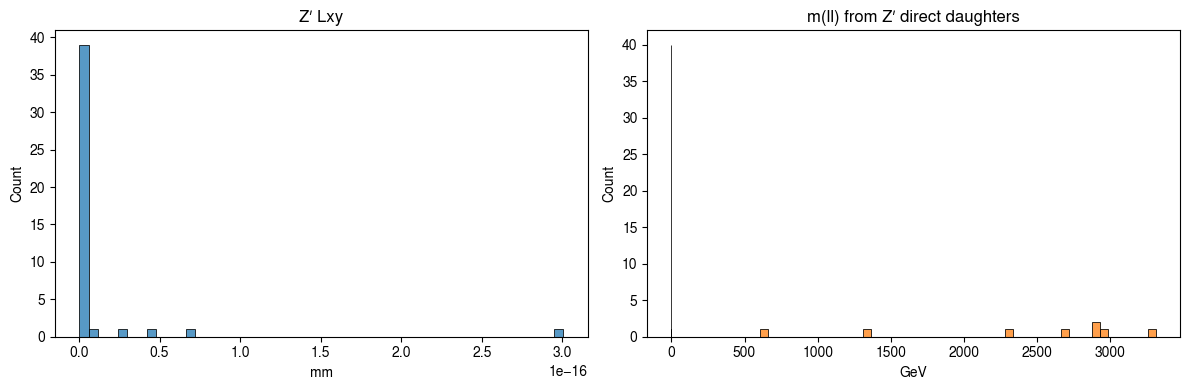

In [18]:
# Promptness + dilepton mass peak
import seaborn as sns
import matplotlib.pyplot as plt

z = compute_zprime_flight_lengths(particles, zprime_pdg=32)
if len(z):
    print("Z′ vertex→endpoint displacement summary (mm)")
    display(z[["L", "Lxy"]].describe(percentiles=[0.5, 0.9, 0.99]))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(z["Lxy"], bins=50, ax=ax[0])
    ax[0].set_title("Z′ Lxy")
    ax[0].set_xlabel("mm")

    sns.histplot(z["L"], bins=50, ax=ax[1])
    ax[1].set_title("Z′ L (3D)")
    ax[1].set_xlabel("mm")
    plt.tight_layout()

mll_df = dilepton_masses_from_zprime(particles, daughters, zprime_pdg=32)
display(mll_df.head())

if len(mll_df):
    sns.histplot(mll_df["mll"], bins=50)
    plt.title("m(ll) from Z′ direct daughters")
    plt.xlabel("GeV")
    plt.show()

PDG=32 mass summary (GeV)
count      44.000000
mean     2507.001437
std       841.790702
min       604.811914
25%      2290.582984
50%      2929.745362
75%      2950.545217
max      3313.437596
Name: mass, dtype: float64


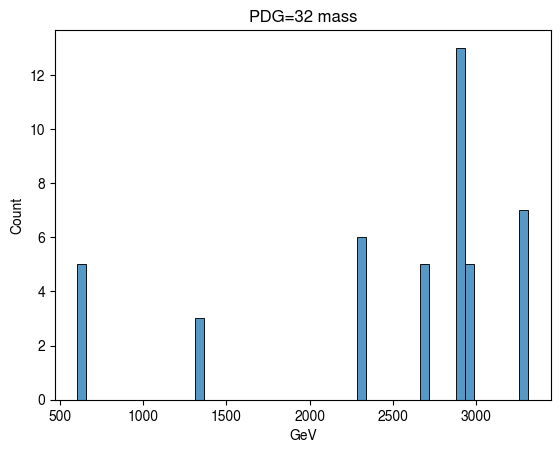


Most common PDGs


PDG
 11            37152
-11            32211
 21             3603
 22             2546
 2212           1853
 211            1623
-211            1589
 111             812
 2112            449
 2               210
 1               148
 321             125
-13              106
-1               105
-321             104
-2               102
 113              96
 221              83
 1000010020       83
 310              81
 223              80
 213              79
-213              73
 13               73
 1000140280       69
 130              68
-2212             68
-311              64
 311              60
 3                59
Name: count, dtype: int64


Most common lepton PDGs


PDG
 11    37152
-11    32211
-13      106
 13       73
Name: count, dtype: int64

In [19]:
# Z′ mass sanity checks + most common PDGs

def _mass_series(particles_df: pd.DataFrame, pdg: int) -> pd.Series:
    """Extract mass values for a given PDG.

    Inputs:
        particles_df: Full particles dataframe.
        pdg: PDG id to filter.

    Outputs:
        Pandas Series of masses (float).
    """
    return particles_df.loc[particles_df["PDG"] == pdg, "mass"].astype(float)


m32 = _mass_series(particles, 32)
print("PDG=32 mass summary (GeV)")
print(m32.describe())
if len(m32):
    sns.histplot(m32, bins=50)
    plt.title("PDG=32 mass")
    plt.xlabel("GeV")
    plt.show()

print("\nMost common PDGs")
display(particles["PDG"].value_counts().head(30))

print("\nMost common lepton PDGs")
leps = particles[particles["PDG"].isin([11, -11, 13, -13])]["PDG"].value_counts()
display(leps)